Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Samples: 545
Area range: 1650.0 - 16200.0
Price range: 1750000.0 - 13300000.0

Learned (on standardized data): m = 0.5360, b = 0.0000
Final cost (MSE): 0.712707

In original units: price = 461.97 * area + 2387308.48
R^2 score: 0.2873


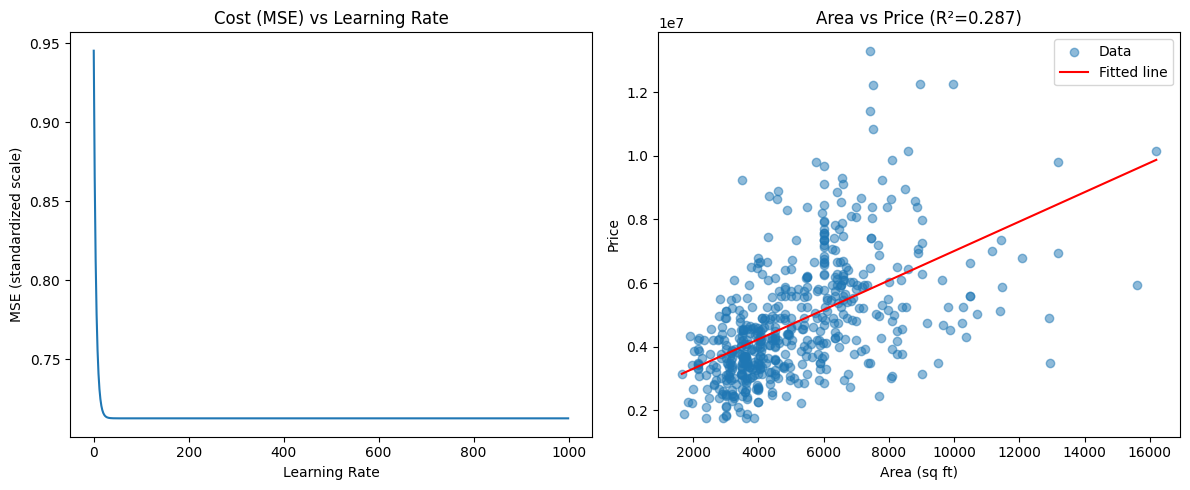

In [5]:
"""
Simple Linear Regression from scratch (NumPy only, no sklearn)
Predicting house `price` from `area` (sq ft) using Housing.csv
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")


# ---------- 1. Load data ----------
df = pd.read_csv(path + "/Housing.csv")
X_raw = df["area"].values.astype(float)   # feature: area
y_raw = df["price"].values.astype(float)  # target: price

print(f"Samples: {len(X_raw)}")
print(f"Area range: {X_raw.min()} - {X_raw.max()}")
print(f"Price range: {y_raw.min()} - {y_raw.max()}")

# ---------- 2. Normalize (standardize) ----------
X_mean, X_std = X_raw.mean(), X_raw.std()
y_mean, y_std = y_raw.mean(), y_raw.std()

X = (X_raw - X_mean) / X_std
y = (y_raw - y_mean) / y_std

n = len(X)

# ---------- 3. Cost function (MSE) ----------
def compute_cost(X, y, m, b):
    y_pred = m * X + b
    return np.mean((y_pred - y) ** 2)

# ---------- 4. Gradient Descent ----------
def gradient_descent(X, y, lr=0.05, learning_rate=1000):
    m, b = 0.0, 0.0   # init slope & intercept
    cost_history = []

    for i in range(learning_rate):
        y_pred = m * X + b
        error = y_pred - y

        # gradients of MSE w.r.t m and b
        dm = (2 / n) * np.dot(error, X)
        db = (2 / n) * np.sum(error)

        m -= lr * dm
        b -= lr * db

        cost_history.append(compute_cost(X, y, m, b))

    return m, b, cost_history

m, b, cost_history = gradient_descent(X, y, lr=0.05, learning_rate=1000)

print(f"\nLearned (on standardized data): m = {m:.4f}, b = {b:.4f}")
print(f"Final cost (MSE): {cost_history[-1]:.6f}")

# ---------- 5. Convert back to original scale ----------
slope_real = m * (y_std / X_std)
intercept_real = y_mean + y_std * b - slope_real * X_mean

print(f"\nIn original units: price = {slope_real:.2f} * area + {intercept_real:.2f}")

# ---------- 6. R^2 score (computed manually) ----------
y_pred_real = slope_real * X_raw + intercept_real
ss_res = np.sum((y_raw - y_pred_real) ** 2)
ss_tot = np.sum((y_raw - y_raw.mean()) ** 2)      
r2 = 1 - ss_res / ss_tot
print(f"R^2 score: {r2:.4f}")

# ---------- 7. Plots ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Cost curve
axes[0].plot(cost_history)
axes[0].set_title("Cost (MSE) vs Learning Rate")
axes[0].set_xlabel("Learning Rate")
axes[0].set_ylabel("MSE (standardized scale)")

# Fit line over data
axes[1].scatter(X_raw, y_raw, alpha=0.5, label="Data")
x_line = np.linspace(X_raw.min(), X_raw.max(), 100)
y_line = slope_real * x_line + intercept_real  # y = mx + c
axes[1].plot(x_line, y_line, color="red", label="Fitted line")
axes[1].set_title(f"Area vs Price (R²={r2:.3f})")
axes[1].set_xlabel("Area (sq ft)")
axes[1].set_ylabel("Price")
axes[1].legend()

plt.tight_layout()
plt.show()         